### LOAN PORTFOLIO MONITORING & EARLY WARNING SYSTEM ###

### Credit Risk Early Warning System using PD Modeling and Explainable Machine Learning ###

**BY ELMA FORTUNATE PHIRI**

**AIM**

To design and implement an end-to-end credit risk monitoring system that proactively identifies deteriorating loans, predicts the probability of default using machine learning, and delivers actionable intelligence to credit teams through an Early Warning System and interactive dashboards.

In [1]:
# IMPORTS 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display,HTML
%matplotlib inline

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import shap
import scipy.sparse as sp

warnings.filterwarnings('ignore')

### Data Loading

In [2]:
credit_risk = pd.read_csv(r"c:\\Users\\My PC\\Desktop\\Datasets\\Loan Portfolio System\\Credit Risk.csv")
credit_risk.head()

,Loan ID,Borrower Name,Branch,RM,Province,City / Town,Loan Product,Sector,Collateral Type,Issue Date,...,Collateral\nValue (USD),LTV\n(%),Revol Util\n(%),DPD,Missed\nPmts,Part\nPmts,Bank Bal\nTrend,Inflation\nExp,Forex\nIncome,Loan Status
0,CNB-010001,Tambudzai Chirwa,Kwekwe Branch,T. Chinyoka,Harare Metropolitan,Harare,School Fees Loan,Transport & logistics,Residential property,20/8/2021,...,"$2,356",74.90%,71.30%,0,2,0,Stable,High,No,Special mention
1,CNB-010002,Chipo Mahachi,Mutare Branch,T. Chinyoka,Mashonaland West,Kadoma,Salary-Backed Loan,Health & pharmaceuticals,Salary cession,8/1/2020,...,$417,40.30%,88.30%,0,1,3,Severely declining,High,No,Watch
2,CNB-010003,Rudo Taruvinga,Gweru Branch,N. Gumbo,Bulawayo Metropolitan,Bulawayo,Green Energy Loan,Transport & logistics,Motor vehicle,31/1/2023,...,"$3,221",37.40%,11.80%,0,1,1,Improving,Low,Yes,Performing
3,CNB-010004,Primrose Majoni,Harare Main,B. Makoni,Masvingo,Chiredzi,Medical Finance,Retail trade,Residential property,30/3/2022,...,$601,116.50%,22.00%,7,0,0,Improving,Medium,No,Special mention
4,CNB-010005,Dumisani Madzivire,Bulawayo Main,P. Mhlanga,Mashonaland West,Kadoma,Microfinance Loan,Construction,Equipment & machinery,14/9/2020,...,"$2,069",88.00%,38.20%,0,1,1,Stable,Medium,Yes,Performing


In [3]:
credit_risk.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Loan ID                 5000 non-null   str  
 1   Borrower Name           5000 non-null   str  
 2   Branch                  5000 non-null   str  
 3   RM                      5000 non-null   str  
 4   Province                5000 non-null   str  
 5   City / Town             5000 non-null   str  
 6   Loan Product            5000 non-null   str  
 7   Sector                  5000 non-null   str  
 8   Collateral Type         5000 non-null   str  
 9   Issue Date              5000 non-null   str  
 10  Maturity Date           5000 non-null   str  
 11  Tenor (Mo)              5000 non-null   int64
 12  Loan Amt
(USD)          5000 non-null   str  
 13  Outstanding
(USD)       5000 non-null   str  
 14  Int Rate
(%)            5000 non-null   str  
 15  Annual Income
(USD)     5000 non

In [4]:
credit_risk.describe()

,Tenor (Mo),Credit\nScore,Emp Length\n(Yrs),DPD,Missed\nPmts,Part\nPmts
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.647800,577.067800,7.026600,26.418800,1.798000,1.190400
std,16.671417,152.245326,5.970747,39.971347,1.783881,1.121427
min,3.000000,280.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,449.000000,3.000000,0.000000,0.000000,0.000000
50%,18.000000,573.000000,5.000000,7.000000,1.000000,1.000000
75%,36.000000,697.000000,10.000000,45.000000,3.000000,2.000000
max,84.000000,849.000000,25.000000,180.000000,7.000000,4.000000


### Data Cleaning

In [5]:
credit_risk.isnull().sum()

Loan ID                      0
Borrower Name                0
Branch                       0
RM                           0
Province                     0
City / Town                  0
Loan Product                 0
Sector                       0
Collateral Type              0
Issue Date                   0
Maturity Date                0
Tenor (Mo)                   0
Loan Amt\n(USD)              0
Outstanding\n(USD)           0
Int Rate\n(%)                0
Annual Income\n(USD)         0
DTI\n(%)                     0
DSCR                         0
Credit\nScore                0
Emp Length\n(Yrs)            0
Collateral\nValue (USD)      0
LTV\n(%)                   328
Revol Util\n(%)              0
DPD                          0
Missed\nPmts                 0
Part\nPmts                   0
Bank Bal\nTrend              0
Inflation\nExp               0
Forex\nIncome                0
Loan Status                  0
dtype: int64

LTV% column contains 328 missing values. Will calculate the missing LTV values and replace them in the missing rows.

In [6]:
# Clean column names
credit_risk.columns = credit_risk.columns.str.replace('\n', ' ').str.strip()
credit_risk.columns

Index(['Loan ID', 'Borrower Name', 'Branch', 'RM', 'Province', 'City / Town',
       'Loan Product', 'Sector', 'Collateral Type', 'Issue Date',
       'Maturity Date', 'Tenor (Mo)', 'Loan Amt (USD)', 'Outstanding (USD)',
       'Int Rate (%)', 'Annual Income (USD)', 'DTI (%)', 'DSCR',
       'Credit Score', 'Emp Length (Yrs)', 'Collateral Value (USD)', 'LTV (%)',
       'Revol Util (%)', 'DPD', 'Missed Pmts', 'Part Pmts', 'Bank Bal Trend',
       'Inflation Exp', 'Forex Income', 'Loan Status'],
      dtype='str')

In [7]:
# Fix date types
credit_risk['Issue Date']    = pd.to_datetime(credit_risk['Issue Date'])
credit_risk['Maturity Date'] = pd.to_datetime(credit_risk['Maturity Date'], format='%d/%m/%Y')

In [8]:
# Fix percentage columns
percent_col = ['Int Rate (%)', 'DTI (%)', 'Revol Util (%)', 'LTV (%)']
for col in percent_col:
    credit_risk[col] = credit_risk[col].astype(str).str.replace('%', '').astype(float)

In [9]:
# Fix DSCR
credit_risk['DSCR'] = credit_risk['DSCR'].astype(str).str.replace('x', '').astype(float)

In [10]:
# Fix currency / numeric columns
cols_to_clean = ['Collateral Value (USD)', 'Loan Amt (USD)', 'Outstanding (USD)', 'Annual Income (USD)']
for col in cols_to_clean:
    credit_risk[col] = pd.to_numeric(
        credit_risk[col].astype(str).str.replace('[^0-9.]', '', regex=True),
        errors='coerce'
    ).astype('Int64')

In [11]:
# Calculate missing LTV values
credit_risk['LTV (%)'] = credit_risk.apply(
    lambda row: (row['Loan Amt (USD)'] / row['Collateral Value (USD)']) * 100
                if pd.isnull(row['LTV (%)']) and row['Collateral Value (USD)'] != 0
                else (0 if row['Collateral Value (USD)'] == 0 else row['LTV (%)']),
    axis=1
)

# Confirm no missing values remain
credit_risk.isnull().sum()

Loan ID                   0
Borrower Name             0
Branch                    0
RM                        0
Province                  0
City / Town               0
Loan Product              0
Sector                    0
Collateral Type           0
Issue Date                0
Maturity Date             0
Tenor (Mo)                0
Loan Amt (USD)            0
Outstanding (USD)         0
Int Rate (%)              0
Annual Income (USD)       0
DTI (%)                   0
DSCR                      0
Credit Score              0
Emp Length (Yrs)          0
Collateral Value (USD)    0
LTV (%)                   0
Revol Util (%)            0
DPD                       0
Missed Pmts               0
Part Pmts                 0
Bank Bal Trend            0
Inflation Exp             0
Forex Income              0
Loan Status               0
dtype: int64

### Exploratory Data Analysis

In [12]:
credit_risk['Loan Status'].value_counts(normalize=True) * 100

Loan Status
Performing         34.44
Special mention    27.86
Watch              21.94
Non-performing     15.76
Name: proportion, dtype: float64

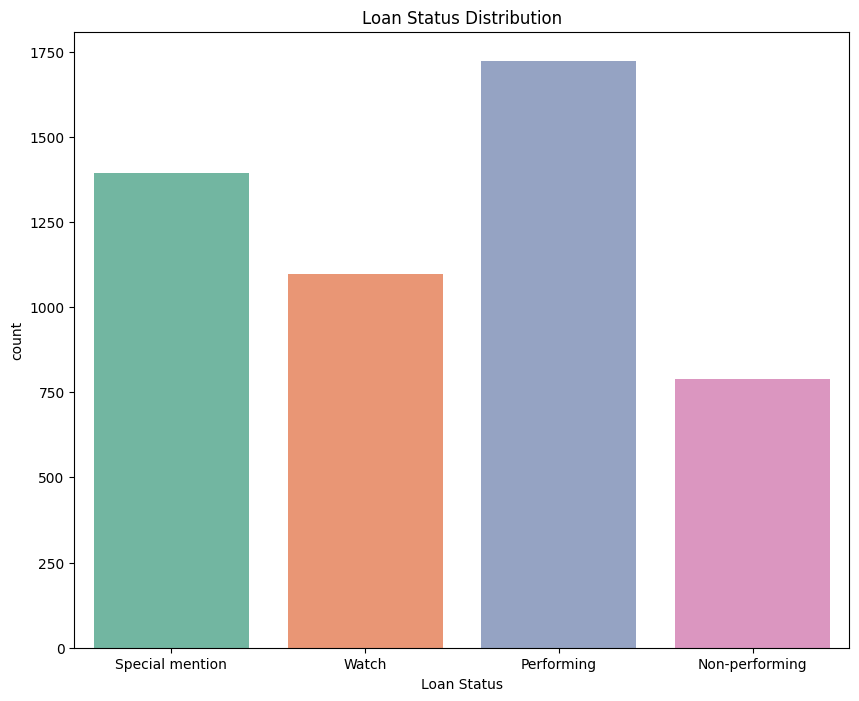

In [13]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Loan Status', data=credit_risk, palette='Set2')
plt.title('Loan Status Distribution')
plt.show()

In [14]:
credit_risk["Province"].value_counts(normalize=True)*100

Province
Harare Metropolitan      26.82
Bulawayo Metropolitan    14.76
Midlands                 13.24
Mashonaland West         12.36
Manicaland               10.74
Masvingo                  7.76
Matabeleland North        4.68
Mashonaland East          4.28
Mashonaland Central       3.06
Matabeleland South        2.30
Name: proportion, dtype: float64

In [15]:
credit_risk["Province"].value_counts()

Province
Harare Metropolitan      1341
Bulawayo Metropolitan     738
Midlands                  662
Mashonaland West          618
Manicaland                537
Masvingo                  388
Matabeleland North        234
Mashonaland East          214
Mashonaland Central       153
Matabeleland South        115
Name: count, dtype: int64

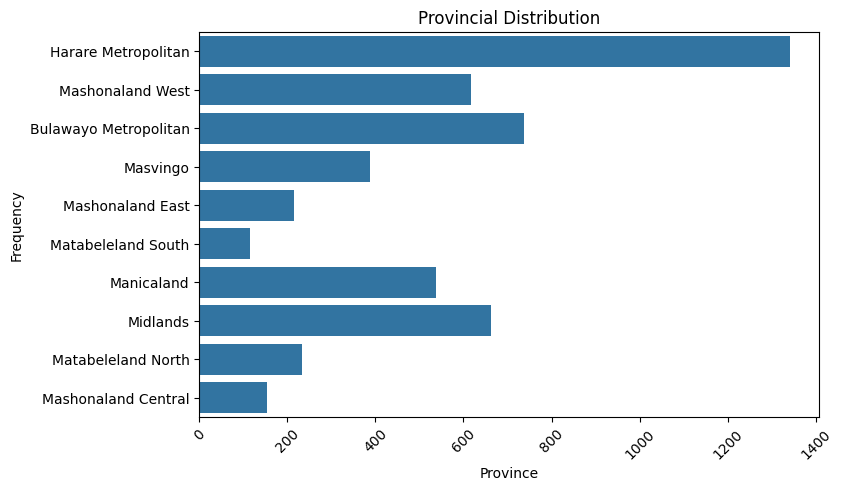

In [16]:
#Borrowers Residence Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data= credit_risk['Province'])
plt.title('Provincial Distribution')
plt.xlabel('Province')
plt.xticks(rotation= 45)
plt.ylabel('Frequency')
plt.show()

In [17]:
credit_risk["Sector"].value_counts(normalize=True)*100

Sector
Agriculture                 17.42
Retail trade                16.36
Manufacturing                9.64
Transport & logistics        8.64
Construction                 6.98
Mining                       6.38
Hospitality & tourism        6.34
Education                    5.46
Health & pharmaceuticals     5.12
Informal trade               4.20
Real estate                  4.16
Financial services           2.94
Energy & utilities           1.84
ICT & telecoms               1.82
Agro-processing              0.98
Food & beverages             0.86
Textiles & clothing          0.86
Name: proportion, dtype: float64

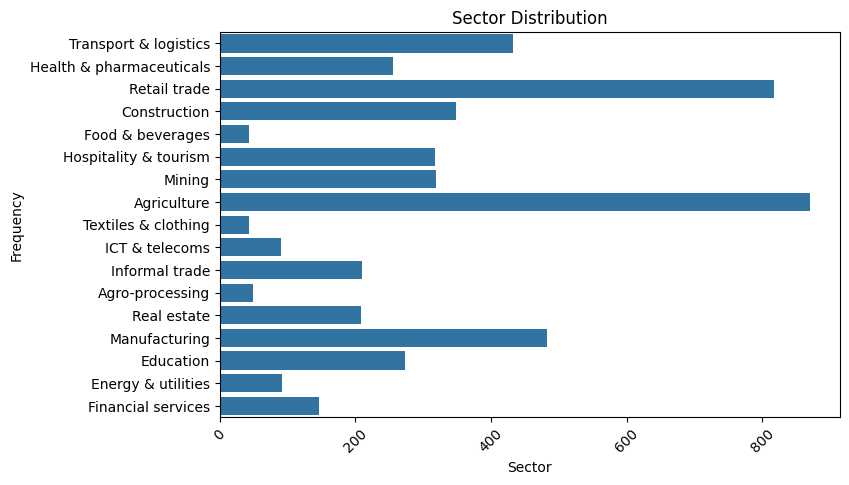

In [18]:
#Sector Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data= credit_risk['Sector'])
plt.title('Sector Distribution')
plt.xlabel('Sector')
plt.xticks(rotation= 45)
plt.ylabel('Frequency')
plt.show()

In [19]:
credit_risk["Loan Product"].value_counts(normalize=True)*100

Loan Product
School Fees Loan              6.54
Digital Business Loan         6.50
Trade Finance Facility        6.22
Import Finance                6.08
Equipment Finance             6.02
Agricultural Input Finance    6.00
Youth Enterprise Loan         5.96
Medical Finance               5.88
Transport Fleet Finance       5.86
Microfinance Loan             5.84
Export Finance                5.78
Salary-Backed Loan            5.70
Property Development Loan     5.68
Agro-processing Loan          5.64
SME Working Capital Loan      5.48
Women in Business Loan        5.42
Green Energy Loan             5.40
Name: proportion, dtype: float64

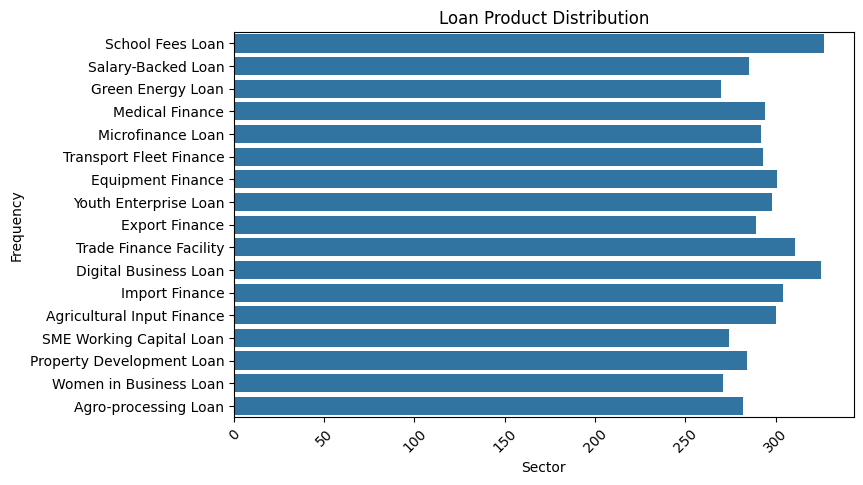

In [20]:
#Loan Product Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data= credit_risk['Loan Product'])
plt.title('Loan Product Distribution')
plt.xlabel('Sector')
plt.xticks(rotation= 45)
plt.ylabel('Frequency')
plt.show()

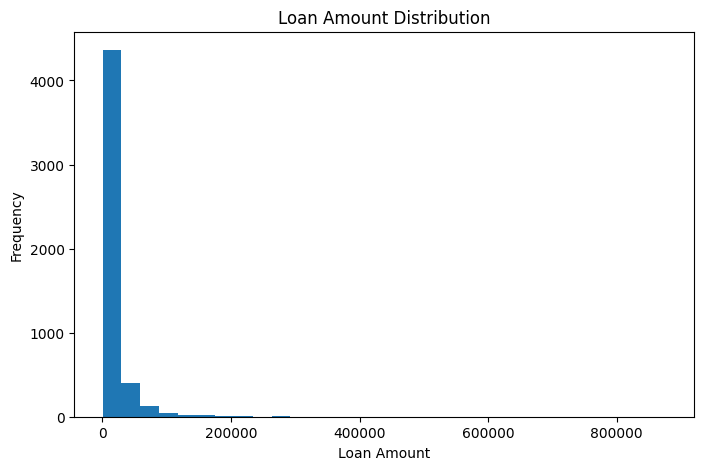

In [21]:
# Loan Amount Distribution
plt.figure(figsize=(8, 5))
plt.hist(credit_risk['Loan Amt (USD)'], bins=30)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

Our histogram shows the data is heavily right-skewed. Most borrowers take small loans, but a few borrow very large amounts. Most loan amounts range between 100,000 and 200,000.

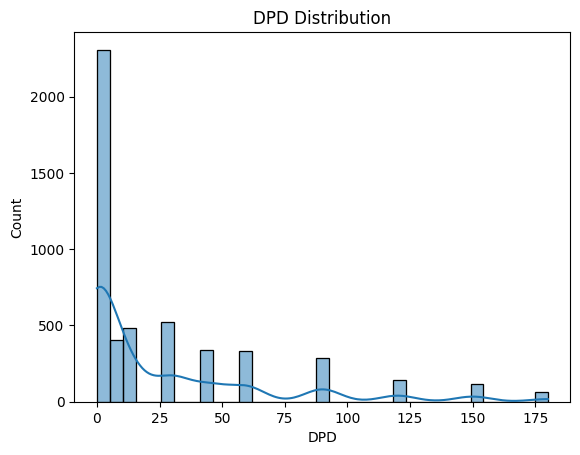

In [22]:
# DPD Distribution
sns.histplot(x='DPD', data=credit_risk, kde=True)
plt.title('DPD Distribution')
plt.show()

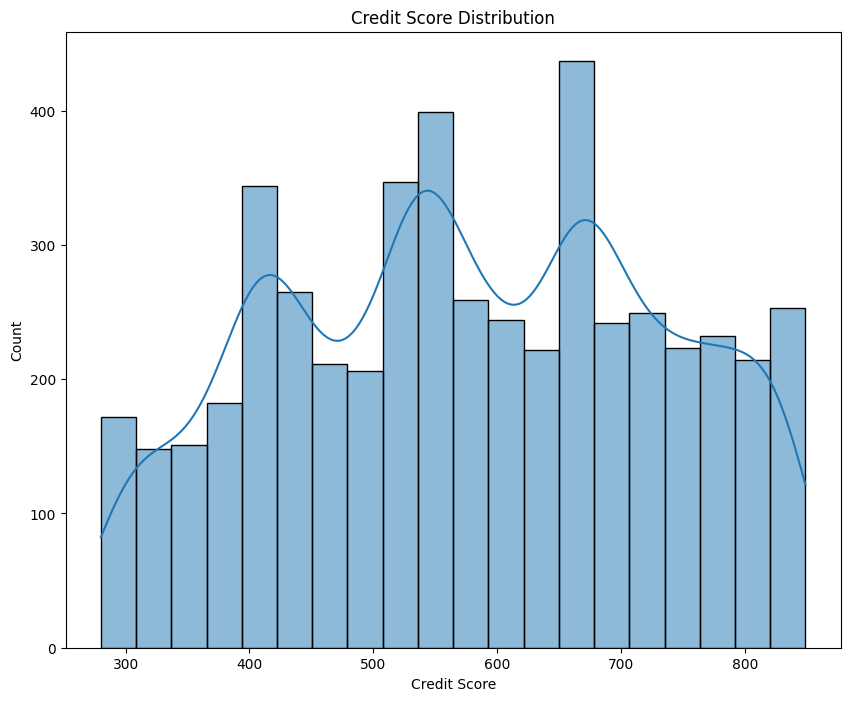

In [23]:
# Credit Score Distribution
plt.figure(figsize=(10, 8))
sns.histplot(x='Credit Score', data=credit_risk, bins=20, kde=True)
plt.title('Credit Score Distribution')
plt.show()

Customers in this dataset have a wide range of creditworthiness from very risky to very reliable borrowers.

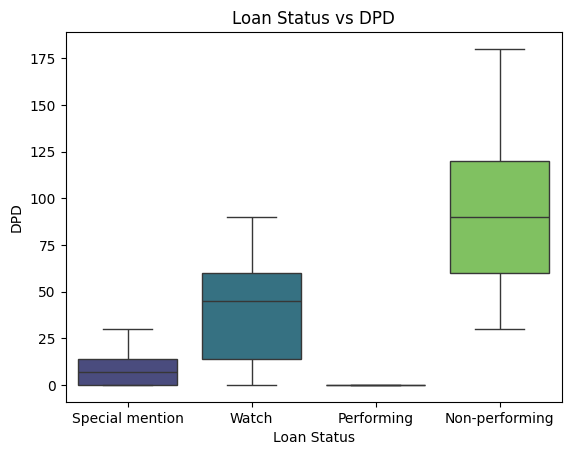

In [24]:
# Loan Status vs DPD
sns.boxplot(x='Loan Status', y='DPD', data=credit_risk, palette='viridis')
plt.title('Loan Status vs DPD')
plt.show()

The analysis shows a clear upward trend in Days Past Due (DPD) as loan status deteriorates. Performing loans exhibit near-zero delinquency, while non-performing loans show significantly higher DPD levels. This confirms that DPD is a strong indicator of loan distress and a critical input to the Early Warning System.

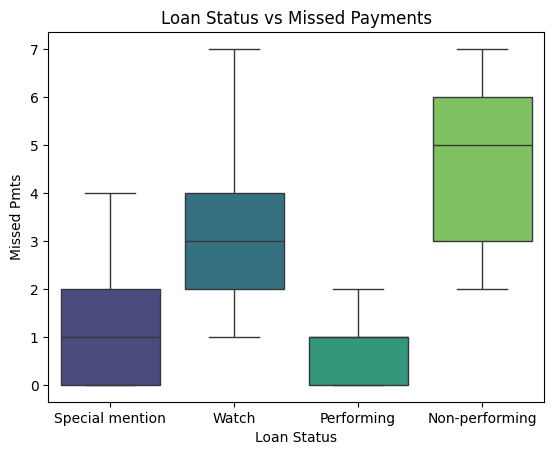

In [25]:
# Loan Status vs Missed Payments
sns.boxplot(x='Loan Status', y='Missed Pmts', data=credit_risk, palette='viridis')
plt.title('Loan Status vs Missed Payments')
plt.show()

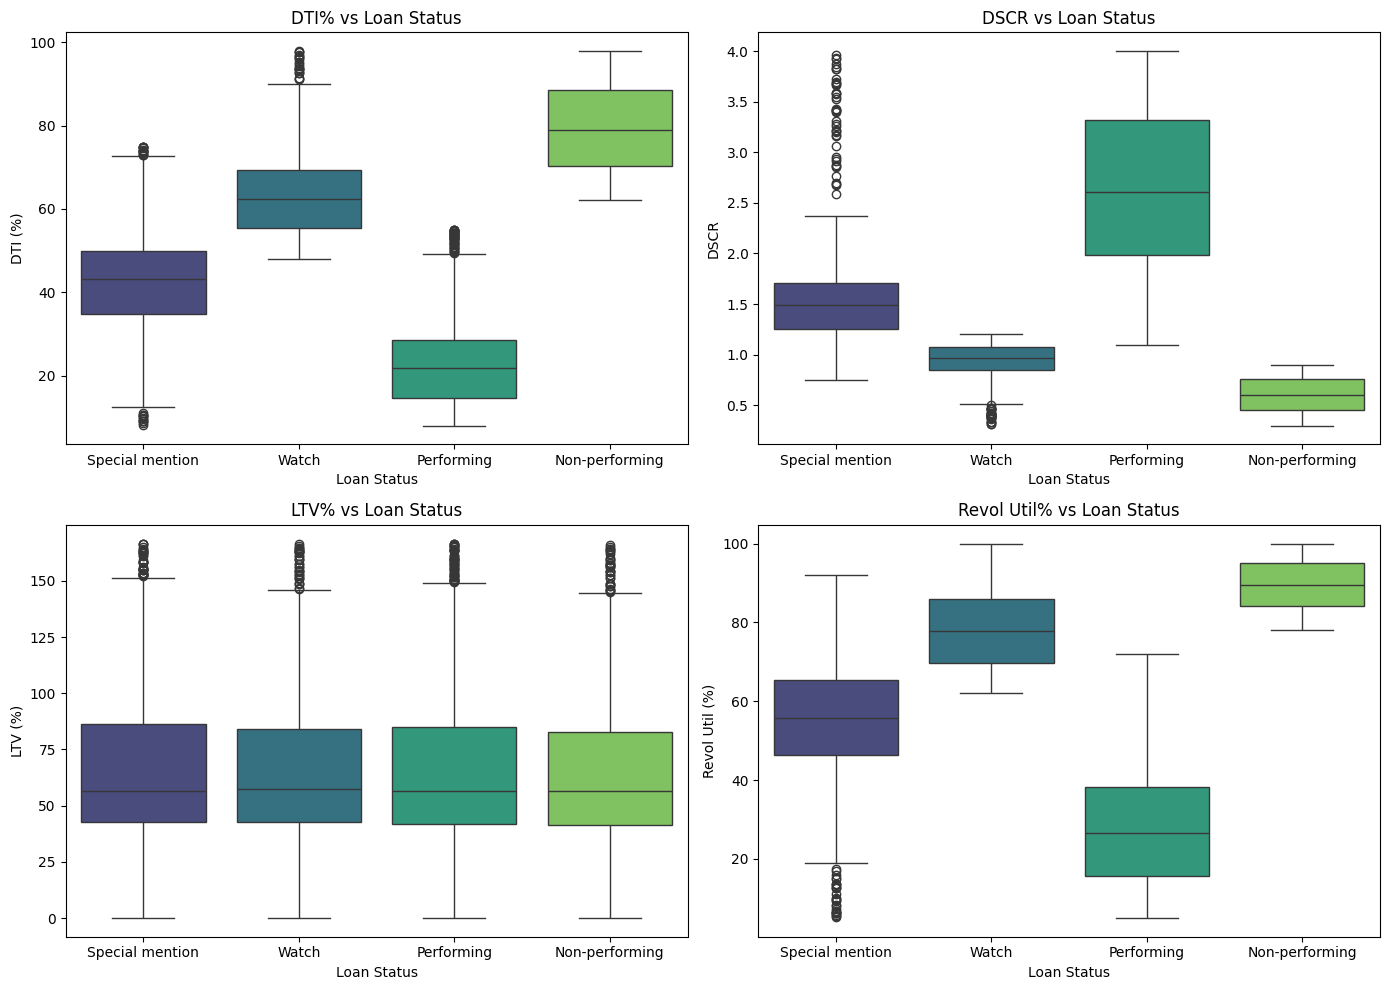

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y='DTI (%)',x='Loan Status', data=credit_risk, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('DTI% vs Loan Status')

sns.boxplot(y='DSCR',x='Loan Status', data=credit_risk, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('DSCR vs Loan Status')

sns.boxplot(y='LTV (%)', x='Loan Status', data=credit_risk, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('LTV% vs Loan Status')

sns.boxplot(y='Revol Util (%)', x='Loan Status', data=credit_risk, palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Revol Util% vs Loan Status')

plt.tight_layout()
plt.show()

DTI% vs Loan Status — Performing loans have the lowest DTI (median ~22%), while Non-performing loans are highest (median ~79%), confirming that borrowers spending more of their income on debt are far more likely to default.

DSCR vs Loan Status — Performing loans show strong debt service coverage (median ~2.6x), while Non-performing and Watch loans cluster below 1.0x, meaning these borrowers cannot cover their debt obligations from income alone.

LTV% vs Loan Status — LTV shows surprisingly little separation across loan statuses (all medians sit around 60%), suggesting collateral coverage alone is a weak differentiator of default risk in this portfolio.

Revol Util% vs Loan Status — Performing loans have the lowest revolving utilisation (median ~28%), while Non-performing borrowers are maxed out near 90%, indicating that heavy reliance on revolving credit is a strong signal of financial distress.

**Correlation Analysis**

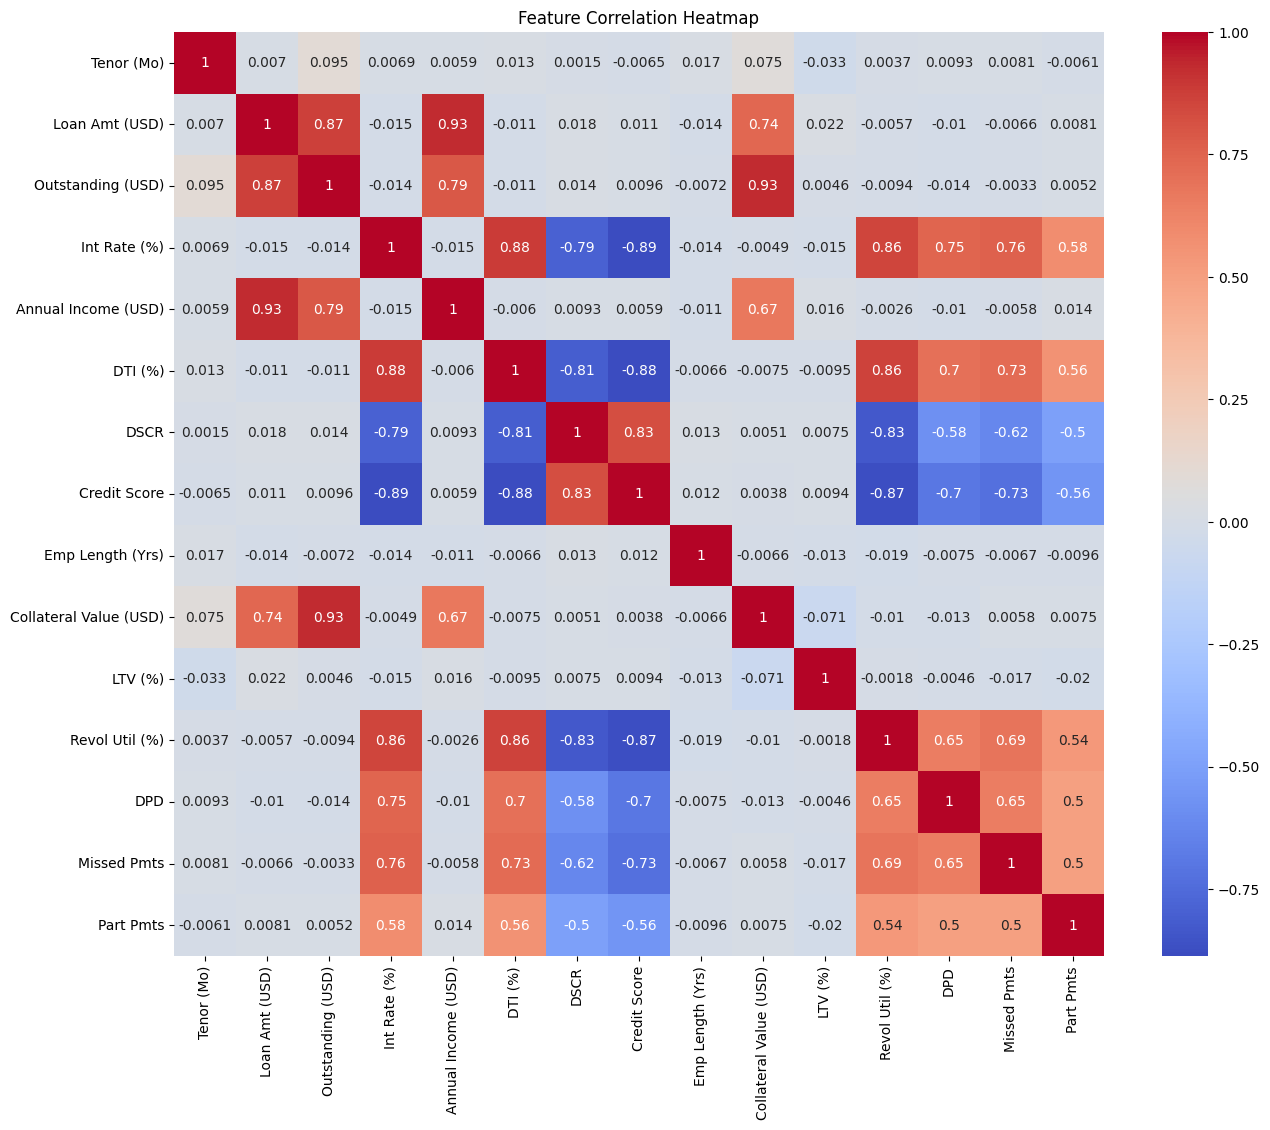

In [27]:
corr = credit_risk.corr(numeric_only=True)
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

People who earn more take bigger loans (normal behaviour). Credit score is the strongest signal of whether someone will repay. Missed and late payments all point to financial stress. Employment length and loan tenor show weak correlation with default risk in this portfolio.

### Early Warning System (EWS)

The EWS uses real-time delinquency data (DPD, Missed Payments) to monitor **existing loans** — this is a portfolio surveillance tool, not a prediction model. 

In [28]:
#EWS FLAGS 
credit_risk['DPD_30_flag']    = (credit_risk['DPD'] > 30).astype(int)
credit_risk['Missed_flag']    = (credit_risk['Missed Pmts'] >= 2).astype(int)
credit_risk['High_LTV%_flag'] = (credit_risk['LTV (%)'] > 80).astype(int)
credit_risk['Low_DSCR_flag']  = (credit_risk['DSCR'] < 1.2).astype(int)
credit_risk['High_DTI_flag']  = (credit_risk['DTI (%)'] > 40).astype(int)
credit_risk['High_Util_flag'] = (credit_risk['Revol Util (%)'] > 70).astype(int)

# Flag crosstabs vs actual loan status
for flag, label in [
    ('DPD_30_flag',    'DPD > 30'),
    ('Missed_flag',    'Missed Pmts >= 2'),
    ('High_LTV%_flag', 'LTV > 80%'),
    ('Low_DSCR_flag',  'DSCR < 1.2'),
    ('High_DTI_flag',  'DTI > 40%'),
    ('High_Util_flag', 'Revol Util > 70%'),
]:
    print(f"\n── {label} ──")
    print(pd.crosstab(credit_risk[flag], credit_risk['Loan Status']))


── DPD > 30 ──
Loan Status  Non-performing  Performing  Special mention  Watch
DPD_30_flag                                                    
0                        63        1722             1393    544
1                       725           0                0    553

── Missed Pmts >= 2 ──
Loan Status  Non-performing  Performing  Special mention  Watch
Missed_flag                                                    
0                         0        1647              896    264
1                       788          75              497    833

── LTV > 80% ──
Loan Status     Non-performing  Performing  Special mention  Watch
High_LTV%_flag                                                    
0                          573        1235              989    793
1                          215         487              404    304

── DSCR < 1.2 ──
Loan Status    Non-performing  Performing  Special mention  Watch
Low_DSCR_flag                                                    
0            

In [29]:
#COMPOSITE RISK SCORE 
credit_risk['Risk_Score'] = (
    credit_risk['DPD_30_flag']    * 3 +   # highest weight: direct delinquency
    credit_risk['Missed_flag']    * 3 +   # highest weight: payment failure
    credit_risk['High_DTI_flag']  * 2 +   # medium weight: income stress
    credit_risk['High_LTV%_flag'] * 2 +   # medium weight: collateral risk
    credit_risk['Low_DSCR_flag']  * 1 +   # lower weight: serviceability
    credit_risk['High_Util_flag'] * 1     # lower weight: credit utilisation
)

print(credit_risk['Risk_Score'].describe())
print(credit_risk['Risk_Score'].value_counts().sort_index())

count    5000.000000
mean        4.561600
std         4.069978
min         0.000000
25%         0.000000
50%         3.000000
75%         9.000000
max        12.000000
Name: Risk_Score, dtype: float64
Risk_Score
0     1358
1       42
2      872
3      237
4      258
5      242
6      201
7      433
8       57
9      221
10     766
11      29
12     284
Name: count, dtype: int64


In [30]:
#RISK BANDS
def assign_risk_band(score):
    if score == 0:
        return 'Green — Performing'
    elif score <= 3:
        return 'Amber — Watch'
    elif score <= 6:
        return 'Orange — Special Mention'
    else:
        return 'Red — Non-Performing'

credit_risk['Risk_Band'] = credit_risk['Risk_Score'].apply(assign_risk_band)

print(credit_risk['Risk_Band'].value_counts())
print()
print(credit_risk['Risk_Band'].value_counts(normalize=True) * 100)

Risk_Band
Red — Non-Performing        1790
Green — Performing          1358
Amber — Watch               1151
Orange — Special Mention     701
Name: count, dtype: int64

Risk_Band
Red — Non-Performing        35.80
Green — Performing          27.16
Amber — Watch               23.02
Orange — Special Mention    14.02
Name: proportion, dtype: float64


In [31]:
#VALIDATE RISK BANDS vs ACTUAL LOAN STATUS
validation = pd.crosstab(
    credit_risk['Risk_Band'],
    credit_risk['Loan Status'],
    normalize='index'
) * 100

print("Risk Band vs Actual Loan Status (%):")
print(validation.round(1))

Risk Band vs Actual Loan Status (%):
Loan Status               Non-performing  Performing  Special mention  Watch
Risk_Band                                                                   
Amber — Watch                        0.0        46.0             51.3    2.7
Green — Performing                   0.0        82.4             17.6    0.0
Orange — Special Mention             0.0         9.3             60.5   30.2
Red — Non-Performing                44.0         0.4              7.8   47.7


In [32]:
#EWS ACTIONS
def assign_ews_action(row):
    band  = row['Risk_Band']
    score = row['Risk_Score']
    if 'Red' in band:
        return 'URGENT — Escalate to Credit Committee'
    elif 'Special Mention' in band:
        return 'HIGH — Relationship Manager to Call Borrower'
    elif 'Watch' in band and score >= 2:
        return 'ELEVATED — Schedule Site Visit'
    elif 'Watch' in band:
        return 'MONITOR — Monthly Check-in Required'
    else:
        return 'ROUTINE — Standard Monitoring'

credit_risk['EWS_Action'] = credit_risk.apply(assign_ews_action, axis=1)
print(credit_risk['EWS_Action'].value_counts())

EWS_Action
URGENT — Escalate to Credit Committee           1790
ROUTINE — Standard Monitoring                   1358
ELEVATED — Schedule Site Visit                  1109
HIGH — Relationship Manager to Call Borrower     701
MONITOR — Monthly Check-in Required               42
Name: count, dtype: int64


Flag Trigger Rate by Risk Band (%):
                          DPD > 30  Missed Pmts ≥ 2  LTV > 80%  DTI > 40%  \
Risk_Band                                                                   
Amber — Watch                  0.0             10.9       49.9       35.4   
Green — Performing             0.0              0.0        0.0        0.0   
Orange — Special Mention       3.9             53.9       37.1       88.2   
Red — Non-Performing          69.9             94.4       32.2      100.0   

                          DSCR < 1.2  Revol Util > 70%  
Risk_Band                                               
Amber — Watch                    9.7               3.7  
Green — Performing               0.0               0.0  
Orange — Special Mention        45.9              22.1  
Red — Non-Performing            96.5              88.5  


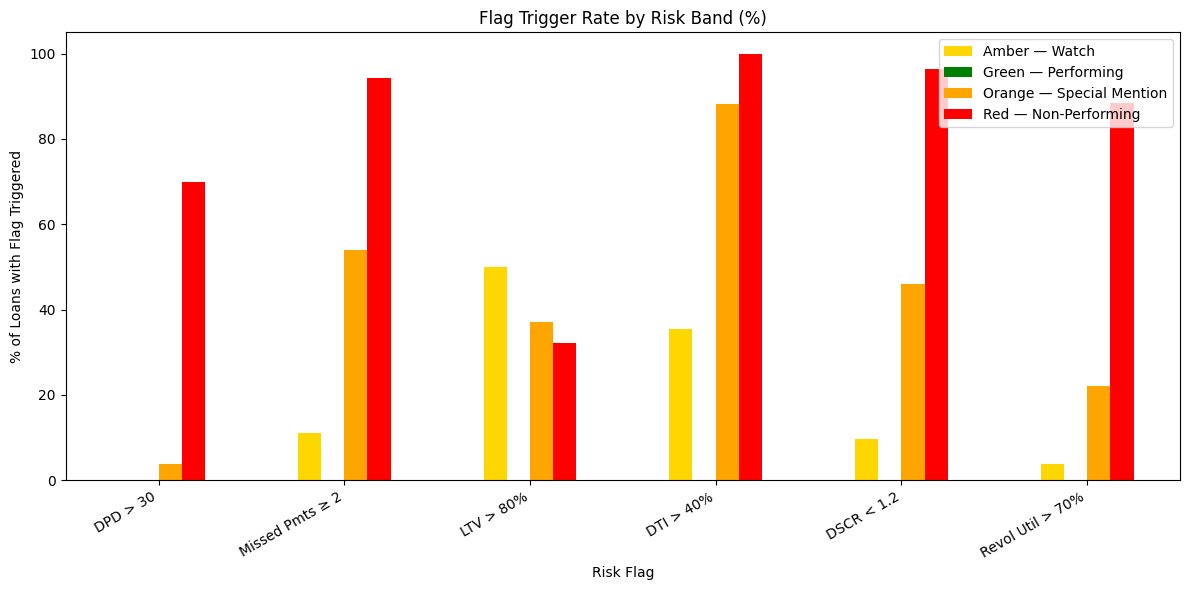

In [33]:
#FLAG BREAKDOWN BY RISK BAND 
flag_cols = ['DPD_30_flag', 'Missed_flag', 'High_LTV%_flag',
             'High_DTI_flag', 'Low_DSCR_flag', 'High_Util_flag']

flag_labels = {
    'DPD_30_flag':    'DPD > 30',
    'Missed_flag':    'Missed Pmts ≥ 2',
    'High_LTV%_flag': 'LTV > 80%',
    'High_DTI_flag':  'DTI > 40%',
    'Low_DSCR_flag':  'DSCR < 1.2',
    'High_Util_flag': 'Revol Util > 70%'
}

flag_breakdown = (credit_risk.groupby('Risk_Band')[flag_cols].mean() * 100).rename(columns=flag_labels)

print("Flag Trigger Rate by Risk Band (%):")
print(flag_breakdown.round(1))

flag_breakdown.T.plot(
    kind='bar',
    figsize=(12, 6),
    color=['gold', 'green', 'orange', 'red']
)
plt.title('Flag Trigger Rate by Risk Band (%)')
plt.ylabel('% of Loans with Flag Triggered')
plt.xlabel('Risk Flag')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

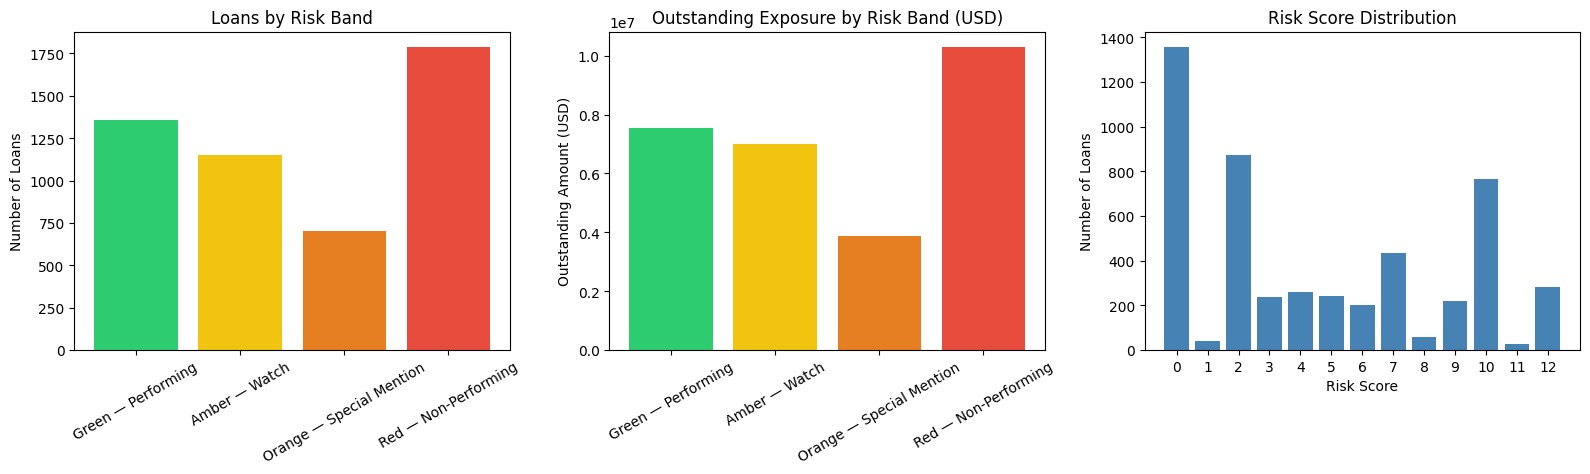

In [34]:
#PORTFOLIO DASHBOARD
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

band_order  = ['Green — Performing', 'Amber — Watch',
               'Orange — Special Mention', 'Red — Non-Performing']
band_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

band_counts   = credit_risk['Risk_Band'].value_counts().reindex(band_order, fill_value=0)
band_exposure = credit_risk.groupby('Risk_Band')['Outstanding (USD)'].sum().reindex(band_order, fill_value=0)
band_scores   = credit_risk['Risk_Score'].value_counts().sort_index()

axes[0].bar(band_counts.index, band_counts.values, color=band_colors)
axes[0].set_title('Loans by Risk Band')
axes[0].set_ylabel('Number of Loans')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(band_exposure.index, band_exposure.values, color=band_colors)
axes[1].set_title('Outstanding Exposure by Risk Band (USD)')
axes[1].set_ylabel('Outstanding Amount (USD)')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(band_scores.index.astype(str), band_scores.values, color='steelblue')
axes[2].set_title('Risk Score Distribution')
axes[2].set_xlabel('Risk Score')
axes[2].set_ylabel('Number of Loans')

plt.tight_layout()
plt.show()

In [35]:
#EWS PRIORITY REPORT 
ews_report = credit_risk[[
    'Loan Product', 'Sector', 'Loan Status', 'Credit Score',
    'DPD', 'Missed Pmts', 'Risk_Score', 'Risk_Band', 'EWS_Action',
    'Outstanding (USD)', 'DPD_30_flag', 'Missed_flag',
    'High_LTV%_flag', 'High_DTI_flag'
]].sort_values('Risk_Score', ascending=False)

urgent = ews_report[ews_report['EWS_Action'].str.contains('URGENT|HIGH')]

print("=" * 60)
print("        EARLY WARNING SYSTEM — PRIORITY REPORT")
print("=" * 60)
print(f"Total Loans Monitored:      {len(credit_risk):,}")
print(f"Loans Flagged Urgent/High:  {len(urgent):,}")
print(f"Total Exposure (Urgent):    ${urgent['Outstanding (USD)'].sum():,.0f}")
print(f"Portfolio at Risk:          {len(urgent) / len(credit_risk) * 100:.1f}%")
print(f"\nAction Breakdown:")
print(credit_risk['EWS_Action'].value_counts().to_string())
print("=" * 60)
print("\nTop 15 Loans Requiring Immediate Attention:")
print(urgent.head(15).to_string())

        EARLY WARNING SYSTEM — PRIORITY REPORT
Total Loans Monitored:      5,000
Loans Flagged Urgent/High:  2,491
Total Exposure (Urgent):    $14,199,319
Portfolio at Risk:          49.8%

Action Breakdown:
EWS_Action
URGENT — Escalate to Credit Committee           1790
ROUTINE — Standard Monitoring                   1358
ELEVATED — Schedule Site Visit                  1109
HIGH — Relationship Manager to Call Borrower     701
MONITOR — Monthly Check-in Required               42

Top 15 Loans Requiring Immediate Attention:
                   Loan Product                 Sector     Loan Status  Credit Score  DPD  Missed Pmts  Risk_Score             Risk_Band                             EWS_Action  Outstanding (USD)  DPD_30_flag  Missed_flag  High_LTV%_flag  High_DTI_flag
1082      Digital Business Loan           Retail trade  Non-performing           395   90            7          12  Red — Non-Performing  URGENT — Escalate to Credit Committee               7028            1            

### Default Probability (PD) Model

In [36]:
#TARGET VARIABLE 
# Normalise loan status string
credit_risk['Loan Status'] = credit_risk['Loan Status'].astype(str).str.strip().str.lower()

# 1 = Default (Special Mention + Non-Performing)
# 0 = Non-Default (Performing + Watch)
default_mapping = {
    'performing':      0,
    'watch':           0,
    'special mention': 1,
    'non-performing':  1
}
credit_risk['Default_Flag'] = credit_risk['Loan Status'].map(default_mapping)
credit_risk = credit_risk.dropna(subset=['Default_Flag'])
credit_risk['Default_Flag'] = credit_risk['Default_Flag'].astype(int)

print(credit_risk['Default_Flag'].value_counts())
print()
print(credit_risk['Default_Flag'].value_counts(normalize=True) * 100)

Default_Flag
0    2819
1    2181
Name: count, dtype: int64

Default_Flag
0    56.38
1    43.62
Name: proportion, dtype: float64


Our dataset is balanced — roughly equal default and non-default cases.

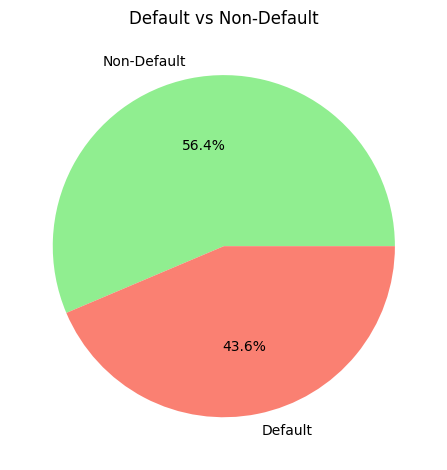

Portfolio at Risk: $32,224,500.00
% of Portfolio at Risk: 42.95%


In [37]:
# Default vs Non-Default pie chart
credit_risk['Default_Flag'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['lightgreen', 'salmon'],
    labels=['Non-Default', 'Default']
)
plt.title('Default vs Non-Default')
plt.tight_layout()
plt.show()

# Portfolio at risk
at_risk = credit_risk[credit_risk['Default_Flag'] == 1]['Loan Amt (USD)'].sum()
total   = credit_risk['Loan Amt (USD)'].sum()
print(f"Portfolio at Risk: ${at_risk:,.2f}")
print(f"% of Portfolio at Risk: {(at_risk / total) * 100:.2f}%")

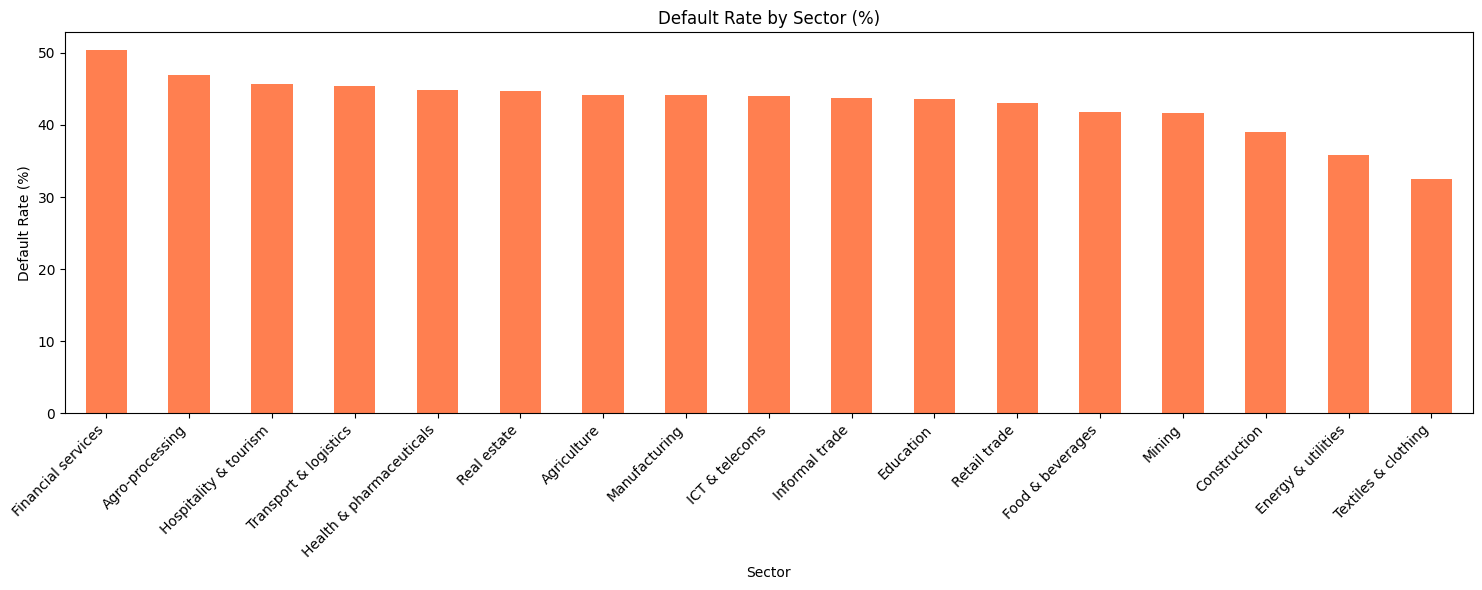

In [38]:
# Default rate by Sector
sector_default = credit_risk.groupby('Sector')['Default_Flag'].agg(['mean', 'sum', 'count'])
sector_default.columns = ['Default_Rate', 'Defaults', 'Total_Loans']
sector_default['Default_Rate'] = sector_default['Default_Rate'] * 100
sector_default = sector_default.sort_values('Default_Rate', ascending=False)

plt.figure(figsize=(15, 6))
sector_default['Default_Rate'].plot(kind='bar', color='coral')
plt.title('Default Rate by Sector (%)')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

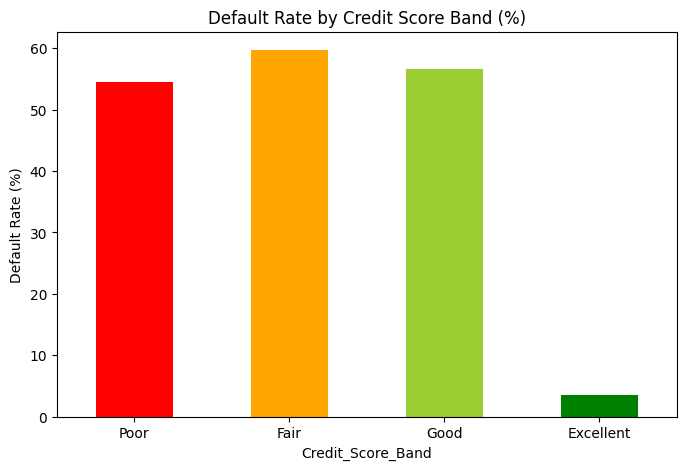

In [39]:
# Default rate by Credit Score band
credit_risk['Credit_Score_Band'] = pd.cut(
    credit_risk['Credit Score'],
    bins=[0, 500, 600, 700, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)

cs_default = credit_risk.groupby('Credit_Score_Band')['Default_Flag'].mean() * 100
plt.figure(figsize=(8, 5))
cs_default.plot(kind='bar', color=['red', 'orange', 'yellowgreen', 'green'])
plt.title('Default Rate by Credit Score Band (%)')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [40]:
# Default rate by Loan Product
product_default = credit_risk.groupby('Loan Product')['Default_Flag'].mean() * 100
print("\nDefault Rate by Loan Product:")
print(product_default.sort_values(ascending=False))


Default Rate by Loan Product:
Loan Product
Youth Enterprise Loan         50.000000
Salary-Backed Loan            48.421053
School Fees Loan              46.788991
Agro-processing Loan          46.099291
Green Energy Loan             45.925926
Import Finance                45.723684
Trade Finance Facility        45.016077
SME Working Capital Loan      43.430657
Microfinance Loan             43.150685
Digital Business Loan         43.076923
Transport Fleet Finance       42.320819
Equipment Finance             42.192691
Medical Finance               41.836735
Property Development Loan     40.492958
Women in Business Loan        40.221402
Export Finance                38.408304
Agricultural Input Finance    38.000000
Name: Default_Flag, dtype: float64


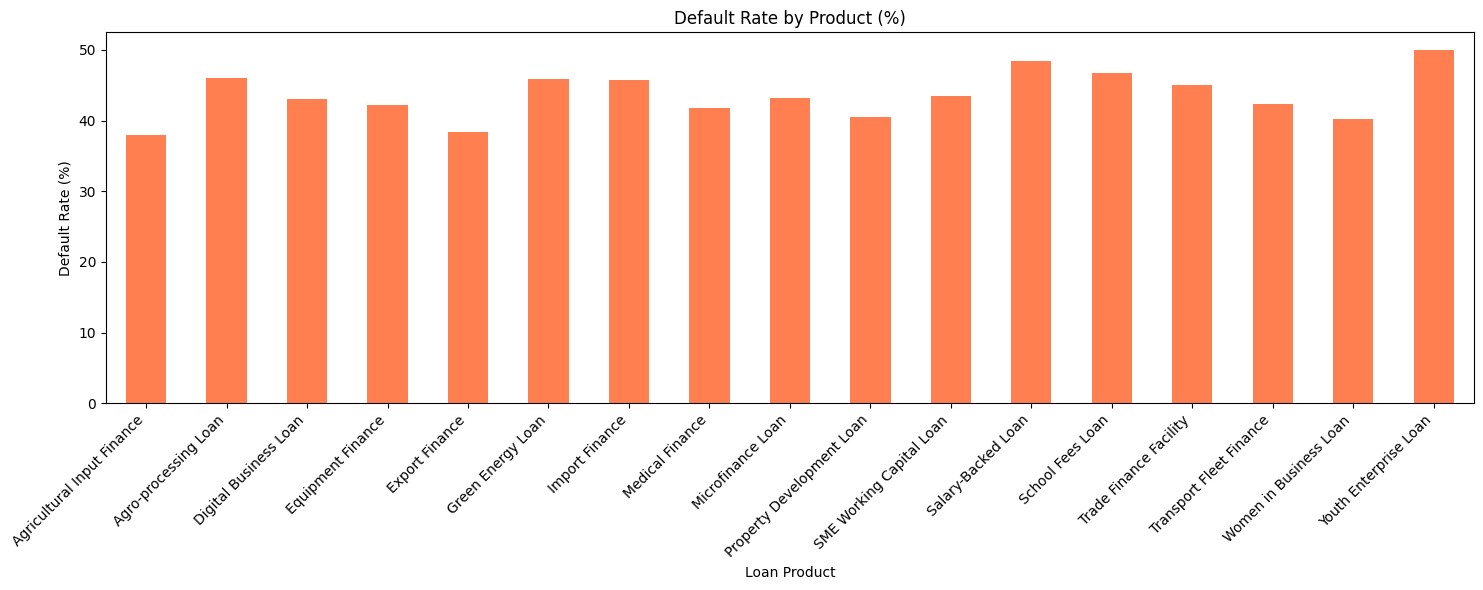

In [41]:
# Default rate by Loan Product
plt.figure(figsize=(15, 6))
product_default.plot(kind='bar', color='coral')
plt.title('Default Rate by Product (%)')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Encoding & Preprocessing

**Note on feature selection:** `DPD`, `Missed Pmts`, `Risk_Score`, and `Risk_Band` are excluded from the model features. These are post-default observables — they only exist because a loan is already delinquent. Including them causes data leakage and produces artificially perfect scores. The EWS uses them for monitoring; the PD model predicts risk from origination-time characteristics only.

In [42]:
#FEATURE SELECTION
drop_cols = [
    # Identifiers
    'Loan ID', 'Borrower Name', 'Issue Date', 'Maturity Date',
    # Admin fields — high cardinality, low predictive value
    'Branch', 'RM',
    # EWS flags (derived from post-default observables)
    'DPD_30_flag', 'Missed_flag', 'High_LTV%_flag',
    'Low_DSCR_flag', 'High_DTI_flag', 'High_Util_flag',
    # EWS outputs (derived)
    'Risk_Score', 'Risk_Band', 'EWS_Action',
    # Post-default observables — DATA LEAKAGE 
    'DPD', 'Missed Pmts',
    # Target encoding helper
    'Credit_Score_Band',
    # Target and loan status string
    'Loan Status', 'Default_Flag'
]

X = credit_risk.drop(columns=drop_cols)
y = credit_risk['Default_Flag']

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Features: {X.shape[1]}  |  numeric: {len(num_cols)}  |  categorical: {len(cat_cols)}")
print(f"\nNumeric:     {num_cols}")
print(f"Categorical: {cat_cols}")

Features: 21  |  numeric: 13  |  categorical: 8

Numeric:     ['Tenor (Mo)', 'Loan Amt (USD)', 'Outstanding (USD)', 'Int Rate (%)', 'Annual Income (USD)', 'DTI (%)', 'DSCR', 'Credit Score', 'Emp Length (Yrs)', 'Collateral Value (USD)', 'LTV (%)', 'Revol Util (%)', 'Part Pmts']
Categorical: ['Province', 'City / Town', 'Loan Product', 'Sector', 'Collateral Type', 'Bank Bal Trend', 'Inflation Exp', 'Forex Income']


In [43]:
#PREPROCESSOR
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Default rate — train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}")

Train: (4000, 21)  |  Test: (1000, 21)
Default rate — train: 43.62%  |  test: 43.60%


### Model Building & Comparison

In [44]:
#MODEL 
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   LogisticRegression(max_iter=1000))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)

    auc_score = roc_auc_score(y_test, y_prob)
    acc       = accuracy_score(y_test, y_pred)

    results[name] = {
        'CV_AUC':   round(cv_scores.mean(), 4),
        'Test_AUC': round(auc_score, 4),
        'Accuracy': round(acc, 4)
    }

    print(f"   CV AUC:   {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"   Test AUC: {auc_score:.4f}")
    print(f"   Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

print("\n📊 Model Comparison Summary:")
print(pd.DataFrame(results).T.sort_values('Test_AUC', ascending=False))


🔹 Training Logistic Regression...
   CV AUC:   0.7420 (±0.0182)
   Test AUC: 0.6862
   Accuracy: 0.6120
              precision    recall  f1-score   support

           0       0.66      0.63      0.65       564
           1       0.55      0.58      0.57       436

    accuracy                           0.61      1000
   macro avg       0.61      0.61      0.61      1000
weighted avg       0.61      0.61      0.61      1000


🔹 Training Decision Tree...
   CV AUC:   0.9072 (±0.0096)
   Test AUC: 0.8893
   Accuracy: 0.8740
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       564
           1       0.86      0.86      0.86       436

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000


🔹 Training Random Forest...
   CV AUC:   0.9148 (±0.0061)
   Test AUC: 0.9106
   Accuracy: 0.8980
              precision    recall  f1-score

### ROC Curve Comparison

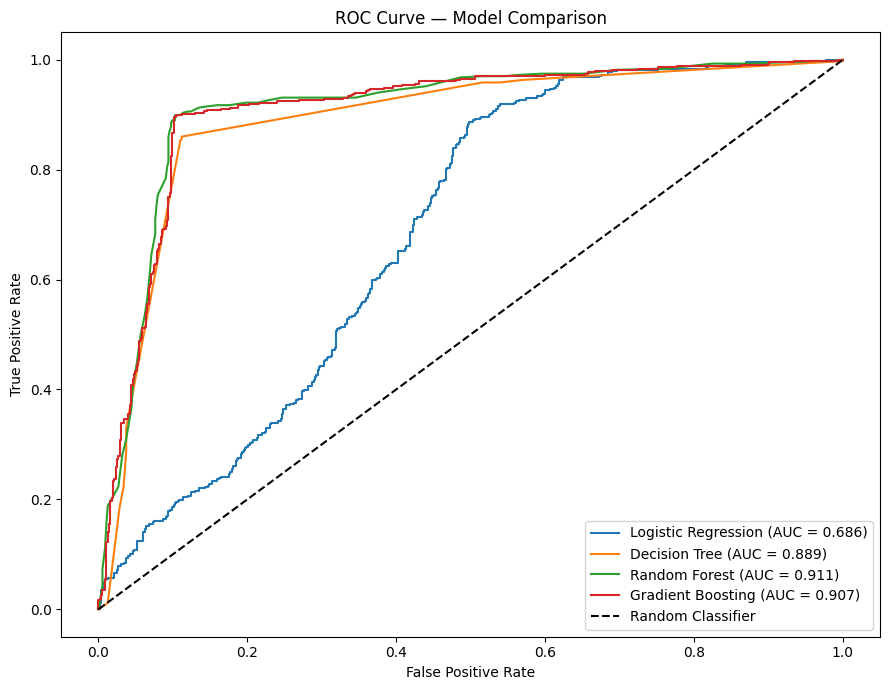

In [45]:
plt.figure(figsize=(9, 7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

The further a curve bends toward the top-left corner, the better the model is at catching defaults without raising too many false alarms.
Random Forest and Gradient Boosting are almost identical and both excellent — they correctly identify most defaulters early. Decision Tree is good but slightly less consistent. Logistic Regression is the weakest by far; at certain points it's barely better than flipping a coin, so don't use it for actual credit decisions.

### Model Explainability — SHAP

Using the best-performing model (Random Forest) to explain which features drive default predictions.

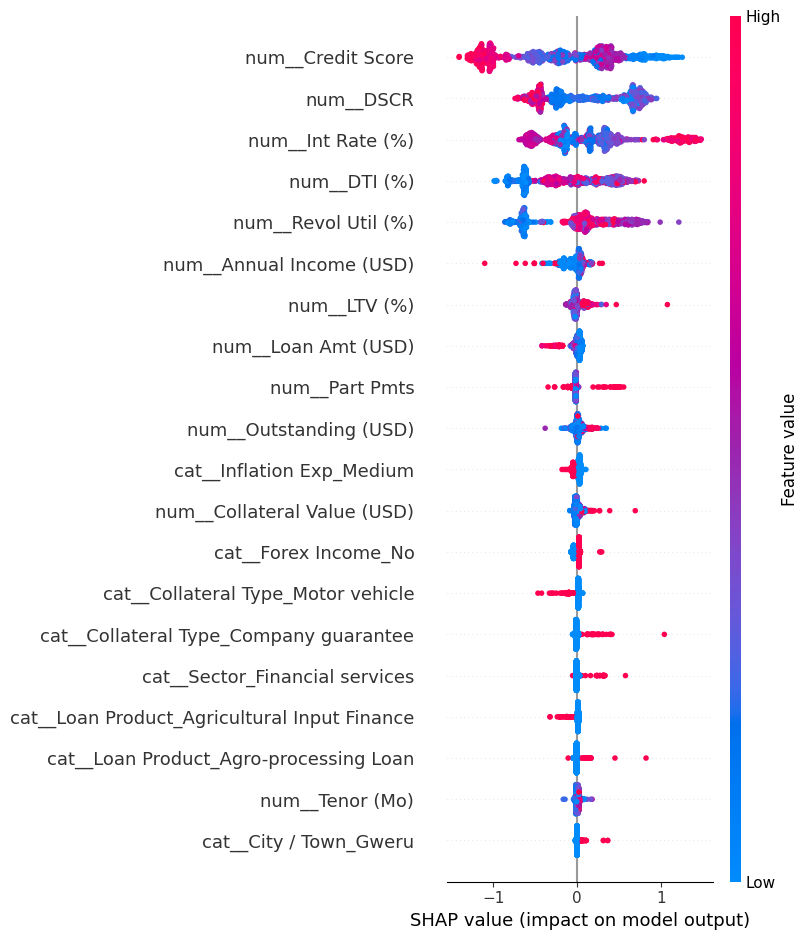

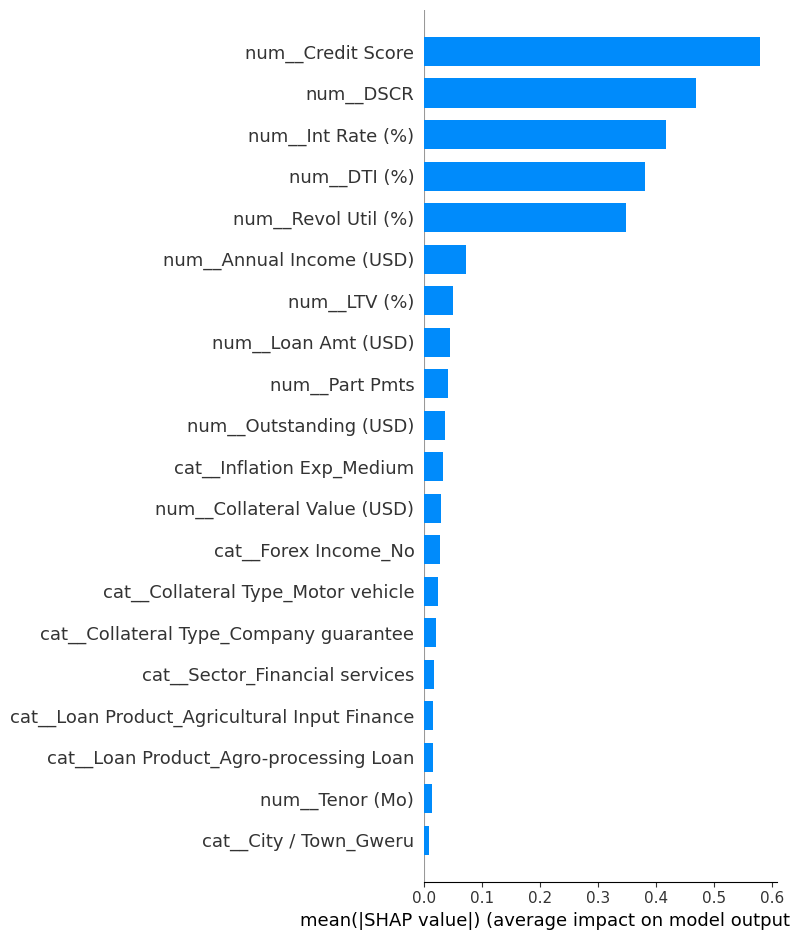

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [46]:
#Shap Explanability

#Train best model

best_model = models['Gradient Boosting']
best_model.fit(X_train, y_train)

#Extract pipeline parts

preprocessor = best_model.named_steps['preprocessor']
classifier = best_model.named_steps['classifier']


#Transform test data

X_test_trans = preprocessor.transform(X_test)

# Handle sparse matrix if needed
if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

X_test_trans = np.asarray(X_test_trans, dtype=np.float64)


#Get FEATURE NAMES 
feature_names = preprocessor.get_feature_names_out()


#SHAP EXPLAINER

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_trans)


#GLOBAL EXPLANATION

shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names
)

# Feature importance bar plot
shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    plot_type="bar"
)


#LOAN-LEVEL EXPLANATION (EWS USE CASE)

i = 0  # change index for different loans

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_trans[i],
        feature_names=feature_names
    )
)

#HUMAN-READABLE OUTPUT
def explain_loan(i):
    explanation = pd.DataFrame({
        "Feature": feature_names,
        "SHAP Value": shap_values[i]
    }).sort_values(by="SHAP Value", ascending=False)

    print("\n🔴 Top Risk Drivers:")
    print(explanation.head(5))

    print("\n🟢 Protective Factors:")
    print(explanation.tail(5))

# Example
explain_loan(0)

### Key Findings from SHAP

1. **Credit Score** — dominant predictor. Low scores (blue) strongly increase default probability; high scores (red) reduce it.
2. **DSCR** — high debt service coverage (red) protects against default; low DSCR (blue) is a warning sign.
3. **Interest Rate** — higher rates (red) increase default probability, reflecting that riskier borrowers received higher rates at origination.
4. **Revolving Utilisation** — high utilisation signals financial stretch and increases default risk.
5. **DTI** — high debt-to-income (red) consistently pushes toward default.

The bottom half of the chart (collateral type, sector, loan product) shows these categorical features have much smaller individual effects — portfolio risk is primarily driven by borrower-level financial ratios, not product type or sector.

## EARLY WARNING SYSTEM (EWS) using PD

In [47]:
# Predict PD
credit_risk['PD'] = best_model.predict_proba(X)[:, 1]

# Risk band rules
def risk_band(pd):
    if pd < 0.2:
        return "LOW"
    elif pd < 0.5:
        return "WATCH"
    else:
        return "HIGH RISK"

credit_risk['Risk_Band'] = credit_risk['PD'].apply(risk_band)

In [48]:
def ews_action(row):
    if row['PD'] > 0.7:
        return "URGENT — Credit Committee Review"
    elif row['PD'] > 0.5:
        return "HIGH — RM Call Required"
    elif row['PD'] > 0.3:
        return "WATCH — Monitor Closely"
    else:
        return "LOW — Routine Monitoring"

credit_risk['EWS_Action'] = credit_risk.apply(ews_action, axis=1)

In [49]:
def explain_risk(i):
    shap_vals = shap_values[i]
    features = preprocessor.get_feature_names_out()

    explanation = pd.DataFrame({
        "Feature": features,
        "Impact": shap_vals
    }).sort_values(by="Impact", ascending=False)

    print("\n🔴 Risk Drivers:")
    print(explanation.head(5))

    print("\n🟢 Protective Factors:")
    print(explanation.tail(5))

explain_risk(0)


🔴 Risk Drivers:
                Feature    Impact
6             num__DSCR  0.762400
11  num__Revol Util (%)  0.518077
5          num__DTI (%)  0.482965
7     num__Credit Score  0.310328
3     num__Int Rate (%)  0.216802

🟢 Protective Factors:
                            Feature    Impact
103           cat__Forex Income_Yes -0.007664
70   cat__Sector_Financial services -0.009317
12                   num__Part Pmts -0.019301
10                     num__LTV (%) -0.044007
4          num__Annual Income (USD) -0.215052


In [51]:
ews_report = credit_risk[[
    'PD',
    'Risk_Band',
    'EWS_Action',
    'Outstanding (USD)'
]]

print("\n=== EARLY WARNING SYSTEM SUMMARY ===")
print(ews_report['Risk_Band'].value_counts()) 

print("\nTotal Exposure at Risk:")
print(ews_report[ews_report['Risk_Band'] == 'HIGH RISK']['Outstanding (USD)'].sum())


=== EARLY WARNING SYSTEM SUMMARY ===
Risk_Band
LOW          2422
HIGH RISK    2249
WATCH         329
Name: count, dtype: int64

Total Exposure at Risk:
12607369


In [52]:
#Function to test a new customer
def predict_customer(
    Province,
    City,
    Loan_Product,
    Sector,
    Collateral_Type,
    Tenor_Mo,
    Loan_Amt,
    Outstanding,
    Int_Rate,
    Annual_Income,
    DTI,
    DSCR,
    Credit_Score,
    Emp_Length,
    Collateral_Value,
    LTV,
    Revol_Util,
    Part_Pmts,
    Bank_Bal_Trend,
    Inflation_Exp,
    Forex_Income
):

    customer = pd.DataFrame({
        'Province': [Province],
        'City / Town': [City],
        'Loan Product': [Loan_Product],
        'Sector': [Sector],
        'Collateral Type': [Collateral_Type],
        'Tenor (Mo)': [Tenor_Mo],
        'Loan Amt (USD)': [Loan_Amt],
        'Outstanding (USD)': [Outstanding],
        'Int Rate (%)': [Int_Rate],
        'Annual Income (USD)': [Annual_Income],
        'DTI (%)': [DTI],
        'DSCR': [DSCR],
        'Credit Score': [Credit_Score],
        'Emp Length (Yrs)': [Emp_Length],
        'Collateral Value (USD)': [Collateral_Value],
        'LTV (%)': [LTV],
        'Revol Util (%)': [Revol_Util],
        'Part Pmts': [Part_Pmts], 
        'Bank Bal Trend': [Bank_Bal_Trend],
        'Inflation Exp': [Inflation_Exp],
        'Forex Income': [Forex_Income]
    })

    pd_score = best_model.predict_proba(customer)[0, 1]
    if pd_score < 0.05:
        risk = "LOW"
        color = "green"
        label = "🟢 LOW RISK (GREEN)"

    elif pd_score < 0.15:
        risk = "WATCH"
        color = "orange"
        label = "🟡 WATCH (AMBER)"

    elif pd_score < 0.30:
        risk = "ELEVATED"
        color = "darkorange"
        label = "🟠 ELEVATED RISK"

    else:
        risk = "HIGH RISK"
        color = "red"
        label = "🔴 HIGH RISK (RED)"

    # EWS action
    if pd_score > 0.30:
        action = "URGENT — Credit Committee Review"
    elif pd_score > 0.15:
        action = "HIGH — RM Call Required"
    elif pd_score > 0.05:
        action = "WATCH — Monitor Closely"
    else:
        action = "LOW — Routine Monitoring"

    display(HTML(f"<h3 style='color:{color}'>{label}</h3>"))
    print(f"PD (Probability of Default): {pd_score:.2%}")
    print(f"Risk Band:  {risk}")
    print(f"EWS Action: {action}")


In [55]:
widgets.interact(
    predict_customer,
    Province=["Harare", "Bulawayo", "Manicaland", "Midlands"],
    City=["Harare", "Mutare", "Gweru", "Bulawayo"],
    Loan_Product=["Personal Loan", "Business Loan", "Asset Finance"],
    Sector=["Retail", "Agriculture", "Manufacturing"],
    Collateral_Type=["Property", "Vehicle", "Cash", "None"],
    Tenor_Mo=(6, 120),
    Loan_Amt=(1000, 500000),
    Outstanding=(0, 500000),
    Int_Rate=(1, 50),
    Annual_Income=(1000, 200000),
    DTI=(0, 120, 1),
    DSCR=(0.0, 5.0, 0.1),
    Credit_Score=(300, 850),
    Emp_Length=(0, 40),
    Collateral_Value=(0, 1000000),
    LTV=(0, 200, 1),
    Revol_Util=(0, 100, 1),
    Part_Pmts=(0, 10),
    Bank_Bal_Trend=['Improving', 'Stable', 'Declining', 'Severely declining'],
    Inflation_Exp=(0.0, 1.0, 0.01),
    Forex_Income=[0, 1]
);


interactive(children=(Dropdown(description='Province', options=('Harare', 'Bulawayo', 'Manicaland', 'Midlands'…

In [ ]:
urgent_loans = credit_risk[credit_risk['Risk_Band'] == 'HIGH RISK']
urgent_loans.sort_values('PD', ascending=False).head(10)

,Loan ID,Borrower Name,Branch,RM,Province,City / Town,Loan Product,Sector,Collateral Type,Issue Date,...,High_LTV%_flag,Low_DSCR_flag,High_DTI_flag,High_Util_flag,Risk_Score,Risk_Band,EWS_Action,Default_Flag,Credit_Score_Band,PD
2244,CNB-012245,Nomatter Tembo,Chitungwiza Branch,E. Mapfumo,Mashonaland Central,Bindura,Agro-processing Loan,Transport & logistics,Company guarantee,2022-03-21,...,0,1,1,1,10,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.976884
2249,CNB-012250,Nokuthula Tembo,Kwekwe Branch,P. Mhlanga,Bulawayo Metropolitan,Bulawayo,Import Finance,Agriculture,Equipment & machinery,2022-03-25,...,1,1,1,1,12,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.972106
4897,CNB-014898,Tafadzwa Mamvura,Masvingo Branch,M. Ndlovu,Mashonaland Central,Bindura,Import Finance,Hospitality & tourism,Equipment & machinery,2019-09-02,...,0,1,1,1,7,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.969337
4044,CNB-014045,Zviko Nyandoro,Kwekwe Branch,B. Makoni,Manicaland,Mutare,Property Development Loan,Retail trade,Residential property,2024-06-13,...,0,1,1,1,10,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.969261
1566,CNB-011567,Blessed Gova,Chitungwiza Branch,P. Mhlanga,Manicaland,Mutare,Green Energy Loan,Retail trade,Company guarantee,2023-10-31,...,0,1,1,1,10,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.966221
2541,CNB-012542,Chiedza Molife,Mutare Branch,P. Mhlanga,Harare Metropolitan,Epworth,Transport Fleet Finance,Informal trade,Residential property,2024-04-27,...,0,1,1,1,10,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.965930
2225,CNB-012226,Edmore Chiweshe,Harare Main,E. Mapfumo,Bulawayo Metropolitan,Bulawayo,School Fees Loan,Retail trade,No collateral,2020-11-20,...,0,1,1,1,10,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.965779
1514,CNB-011515,Lucky Majoni,Beitbridge Branch,P. Mhlanga,Matabeleland North,Victoria Falls,Export Finance,Agriculture,Company guarantee,2019-11-03,...,1,1,1,1,9,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.965484
3909,CNB-013910,Nomatter Nyagura,Gweru Branch,R. Ncube,Manicaland,Mutare,Green Energy Loan,Transport & logistics,Motor vehicle,2021-10-25,...,1,1,1,1,12,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.965369
4704,CNB-014705,Tinashe Sithole,Chitungwiza Branch,G. Mutasa,Mashonaland Central,Bindura,Salary-Backed Loan,Informal trade,Stock/inventory pledge,2021-08-01,...,0,1,1,1,10,HIGH RISK,URGENT — Credit Committee Review,1,Poor,0.964175


In [ ]:
# ── Attach PD score to full dataset for EWS export ────────────────────────────
# Get scores for the entire portfolio, not just the test set
X_full = credit_risk.drop(columns=drop_cols)
credit_risk['PD_Score'] = models['Random Forest'].predict_proba(X_full)[:, 1]

# ── Build and export EWS report ───────────────────────────────────────────────
ews_export_cols = [
    # Identifiers
    'Loan ID', 'Borrower Name', 'Branch', 'Sector', 'Loan Product',
    # Financial snapshot
    'Loan Amt (USD)', 'Outstanding (USD)', 'Credit Score',
    'DTI (%)', 'DSCR', 'LTV (%)', 'Revol Util (%)',
    # Delinquency
    'DPD', 'Missed Pmts',
    # EWS outputs
    'Risk_Score', 'Risk_Band', 'EWS_Action',
    'DPD_30_flag', 'Missed_flag', 'High_LTV%_flag',
    'High_DTI_flag', 'Low_DSCR_flag', 'High_Util_flag',
    # Model output
    'PD_Score'
]

ews_export = (
    credit_risk[ews_export_cols]
    .sort_values('Risk_Score', ascending=False)
    .round({'PD_Score': 4, 'DTI (%)': 1, 'DSCR': 2, 'LTV (%)': 1})
)

ews_export.to_csv('ews_report.csv', index=False)
print(f"Exported {len(ews_export):,} loans to ews_report.csv")
print(ews_export.head())


Exported 5,000 loans to ews_report.csv
         Loan ID     Borrower Name              Branch                 Sector  \
1082  CNB-011083     Munashe Nkomo  Chitungwiza Branch           Retail trade   
1086  CNB-011087  Fortune Chiweshe  Chitungwiza Branch          Manufacturing   
4551  CNB-014552    Tatenda Maposa       Bulawayo Main           Retail trade   
1091  CNB-011092    Phenias Molife   Beitbridge Branch  Transport & logistics   
1063  CNB-011064    Tapiwa Ushamba       Kwekwe Branch           Construction   

                   Loan Product  Loan Amt (USD)  Outstanding (USD)  \
1082      Digital Business Loan           25100               7028   
1086          Microfinance Loan            1900                532   
4551             Export Finance             700                196   
1091  Property Development Loan            1500                973   
1063         Salary-Backed Loan            6600               3256   

      Credit Score  DTI (%)  DSCR  ...  Risk_Score  R

In [ ]:
import joblib
import pandas as pd
import json
import os

OUTPUT_DIR = "deployment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Save trained Random Forest pipeline ────────────────────────────────────
# 'models' dict must be in scope (run after the model training cell)
joblib.dump(models['Random Forest'], f"{OUTPUT_DIR}/credit_risk_model.pkl")
print("✅  Model saved →", f"{OUTPUT_DIR}/credit_risk_model.pkl")

# ── 2. Save feature column lists (needed for input validation) ────────────────
feature_meta = {
    "num_cols": list(num_cols),
    "cat_cols": list(cat_cols),
    "drop_cols": drop_cols,
}
with open(f"{OUTPUT_DIR}/feature_meta.json", "w") as f:
    json.dump(feature_meta, f, indent=2)
print("✅  Feature metadata saved →", f"{OUTPUT_DIR}/feature_meta.json")

# ── 3. Export EWS report CSV for Power BI ────────────────────────────────────
# Attach PD score to full dataset
X_full = credit_risk.drop(columns=drop_cols)
credit_risk['PD_Score'] = models['Random Forest'].predict_proba(X_full)[:, 1]

ews_export_cols = [
    'Loan ID', 'Borrower Name', 'Branch', 'Sector', 'Loan Product',
    'Loan Amt (USD)', 'Outstanding (USD)', 'Credit Score',
    'DTI (%)', 'DSCR', 'LTV (%)', 'Revol Util (%)',
    'DPD', 'Missed Pmts',
    'Risk_Score', 'Risk_Band', 'EWS_Action',
    'DPD_30_flag', 'Missed_flag', 'High_LTV%_flag',
    'High_DTI_flag', 'Low_DSCR_flag', 'High_Util_flag',
    'PD_Score', 'Default_Flag'
]

# Keep only columns that exist
ews_export_cols = [c for c in ews_export_cols if c in credit_risk.columns]

ews_export = (
    credit_risk[ews_export_cols]
    .sort_values('Risk_Score', ascending=False)
    .round({'PD_Score': 4, 'DTI (%)': 1, 'DSCR': 2, 'LTV (%)': 1})
)

ews_export.to_csv(f"{OUTPUT_DIR}/ews_report.csv", index=False)
print(f"✅  EWS report exported → {OUTPUT_DIR}/ews_report.csv  ({len(ews_export):,} loans)")

# ── 4. Export PD scores only (lightweight Power BI table) ─────────────────────
pd_export = credit_risk[['Loan ID', 'PD_Score', 'Risk_Band', 'EWS_Action',
                          'Outstanding (USD)', 'Sector', 'Loan Product']].copy()
pd_export.to_csv(f"{OUTPUT_DIR}/pd_scores.csv", index=False)
print(f"✅  PD scores exported  → {OUTPUT_DIR}/pd_scores.csv")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n📦 Deployment package ready in:", OUTPUT_DIR)
print("   Files to copy to server:")
print("   ├── credit_risk_model.pkl")
print("   ├── feature_meta.json")
print("   ├── ews_report.csv        ← load into Power BI")
print("   └── pd_scores.csv         ← load into Power BI")
print("\n   Then copy app.py and requirements.txt to the server and run:")
print("   pip install -r requirements.txt")
print("   python app.py")

✅  Model saved → deployment/credit_risk_model.pkl
✅  Feature metadata saved → deployment/feature_meta.json
✅  EWS report exported → deployment/ews_report.csv  (5,000 loans)
✅  PD scores exported  → deployment/pd_scores.csv

📦 Deployment package ready in: deployment
   Files to copy to server:
   ├── credit_risk_model.pkl
   ├── feature_meta.json
   ├── ews_report.csv        ← load into Power BI
   └── pd_scores.csv         ← load into Power BI

   Then copy app.py and requirements.txt to the server and run:
   pip install -r requirements.txt
   python app.py


In [ ]:
pip install flask joblib 


In [ ]:
# Run this in a notebook cell — installs and starts the API without a terminal
import subprocess, sys

# Install flask
subprocess.run([sys.executable, "-m", "pip", "install", "flask", "joblib"], check=True)

# Start the API in the background
import threading

def run_app():
    subprocess.run([sys.executable, "app.py"])

thread = threading.Thread(target=run_app, daemon=True)
thread.start()

print("✅ API starting at http://localhost:5000")
print("Test it in your browser: http://localhost:5000/health")

CalledProcessError: Command '['c:\\Users\\My PC\\AppData\\Local\\Programs\\Python\\Python314\\python.exe', '-m', 'pip', 'install', 'flask', 'joblib']' returned non-zero exit status 1.

In [ ]:

from datetime import date, timedelta
from pathlib import Path
DEPLOYMENT_DIR = Path(r"c:\Users\My PC\Desktop\Datasets\Loan Portfolio System\deployment")
MASTER_CSV     = Path(r"c:\Users\My PC\Desktop\Datasets\Loan Portfolio System\data\ews_master.csv")

DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)
MASTER_CSV.parent.mkdir(parents=True, exist_ok=True)

# ── Step 1: stamp today's date ─────────────────────────────────────────────────
today_str = date.today().isoformat()   # e.g. "2026-05-02"
snapshot  = ews_export.copy()          # ews_export already exists from your notebook
snapshot["Report_Date"] = today_str

# ── Step 2: load master and get yesterday's PD scores ─────────────────────────
if MASTER_CSV.exists():
    master = pd.read_csv(MASTER_CSV, low_memory=False)
    master["Report_Date"] = master["Report_Date"].astype(str)

    yesterday = (date.today() - timedelta(days=1)).isoformat()
    yest_scores = (
        master[master["Report_Date"] == yesterday][["Loan ID", "PD_Score"]]
        .rename(columns={"PD_Score": "PD_Score_Yesterday"})
    )

    if not yest_scores.empty:
        snapshot = snapshot.merge(yest_scores, on="Loan ID", how="left")
        snapshot["PD_Change_1D"] = (snapshot["PD_Score"] - snapshot["PD_Score_Yesterday"]).round(4)
        snapshot["Deteriorating"] = (snapshot["PD_Change_1D"] > 0.05).astype(int)
    else:
        snapshot["PD_Score_Yesterday"] = np.nan
        snapshot["PD_Change_1D"]       = np.nan
        snapshot["Deteriorating"]      = 0

    # Remove today's rows if re-running (makes it safe to run multiple times)
    master = master[master["Report_Date"] != today_str]
    master = pd.concat([master, snapshot], ignore_index=True)

else:
    # Very first run — no history yet
    snapshot["PD_Score_Yesterday"] = np.nan
    snapshot["PD_Change_1D"]       = np.nan
    snapshot["Deteriorating"]      = 0
    master = snapshot.copy()

# ── Step 3: save both files ────────────────────────────────────────────────────
master.to_csv(MASTER_CSV, index=False)
snapshot.to_csv(DEPLOYMENT_DIR / "ews_report.csv", index=False)

print(f"✅ ews_report.csv updated    → {DEPLOYMENT_DIR / 'ews_report.csv'}")
print(f"✅ ews_master.csv updated    → {MASTER_CSV}")
print(f"   Total historical rows    : {len(master):,}")
print(f"   Days of history          : {master['Report_Date'].nunique()}")

# ── Step 4: print drift summary ───────────────────────────────────────────────
total = len(snapshot)
print(f"\n{'='*55}")
print(f"  EWS SNAPSHOT — {today_str}   ({total:,} loans)")
print(f"{'='*55}")

band_counts = snapshot["Risk_Band"].value_counts()
for band, count in band_counts.items():
    pct = count / total * 100
    print(f"  {band:<25}: {count:>5,}  ({pct:.1f}%)")

exposure_at_risk = snapshot[snapshot["Risk_Band"] == "HIGH RISK"]["Outstanding (USD)"].sum()
total_exposure   = snapshot["Outstanding (USD)"].sum()
print(f"\n  Exposure at risk (HIGH)  : ${exposure_at_risk:>15,.0f}")
print(f"  Total portfolio          : ${total_exposure:>15,.0f}")
print(f"  % at risk                : {exposure_at_risk/total_exposure*100:.1f}%")

if snapshot["PD_Change_1D"].notna().any():
    det = snapshot[snapshot["Deteriorating"] == 1]
    print(f"\n  Deteriorating loans      : {len(det):,}  (PD moved up >0.05 since yesterday)")
    if not det.empty:
        top5 = det.nlargest(5, "PD_Change_1D")[["Loan ID", "Borrower Name", "PD_Score", "PD_Change_1D"]]
        print("\n  Top 5 fastest moving:")
        print(f"  {'Loan ID':<12} {'Borrower':<25} {'PD Score':>8} {'Change':>8}")
        print(f"  {'-'*55}")
        for _, row in top5.iterrows():
            print(f"  {str(row['Loan ID']):<12} {str(row['Borrower Name'])[:24]:<25} {row['PD_Score']:>8.4f} {row['PD_Change_1D']:>+8.4f}")

print(f"\n{'='*55}")
print("  Power BI will pick up changes on next scheduled refresh.")
print(f"{'='*55}\n")


✅ ews_report.csv updated    → c:\Users\My PC\Desktop\Datasets\Loan Portfolio System\deployment\ews_report.csv
✅ ews_master.csv updated    → c:\Users\My PC\Desktop\Datasets\Loan Portfolio System\data\ews_master.csv
   Total historical rows    : 15,000
   Days of history          : 3

  EWS SNAPSHOT — 2026-06-08   (5,000 loans)
  LOW                      : 2,422  (48.4%)
  HIGH RISK                : 2,249  (45.0%)
  WATCH                    :   329  (6.6%)

  Exposure at risk (HIGH)  : $     12,607,369
  Total portfolio          : $     28,755,422
  % at risk                : 43.8%

  Power BI will pick up changes on next scheduled refresh.



In [ ]:
pip install -r requirementa.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirementa.txt'
